# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score, adjusted_rand_score, normalized_mutual_info_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram
sns.set_theme(style="whitegrid"); RANDOM_STATE=42

### Leer conjunto de datos y primer vistazo

In [2]:
df=pd.read_csv("data/mushrooms.csv"); df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploración de datos

In [3]:
print(df.shape); df.describe(include="all").T

(8124, 23)


,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


In [4]:
df.dtypes.to_frame("tipo")

,tipo
class,str
cap-shape,str
cap-surface,str
cap-color,str
bruises,str
odor,str
gill-attachment,str
gill-spacing,str
gill-size,str
gill-color,str


#### Calcular el número de nulos de cada feature

In [5]:
df.isna().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [6]:
n_values=pd.DataFrame({"feature":df.columns,"n_values":df.nunique().values}); n_values.sort_values("n_values")

,feature,n_values
16,veil-type,1
0,class,2
6,gill-attachment,2
7,gill-spacing,2
10,stalk-shape,2
8,gill-size,2
4,bruises,2
18,ring-number,3
12,stalk-surface-above-ring,4
17,veil-color,4


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

#### Tratar aquellos valores que entendamos que sean nulos

In [7]:
df["stalk-root"]=df["stalk-root"].replace("?",np.nan).fillna(df["stalk-root"].replace("?",np.nan).mode().iat[0]); df["stalk-root"].value_counts()

stalk-root
b    6256
e    1120
c     556
r     192
Name: count, dtype: int64

#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [8]:
constant_columns=n_values.query("n_values==1")["feature"].tolist(); df=df.drop(columns=constant_columns); print(constant_columns,df.shape)

['veil-type'] (8124, 22)


#### Separar entre variables predictoras y variable a predecir

In [9]:
y=df["class"].copy(); X=df.drop(columns="class").copy(); print(X.shape)

(8124, 21)


#### Codificar correctamente las variables categóricas a numéricas

In [10]:
X=pd.get_dummies(X,dtype=int); print(X.shape)

(8124, 115)


#### Train / test split

In [11]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

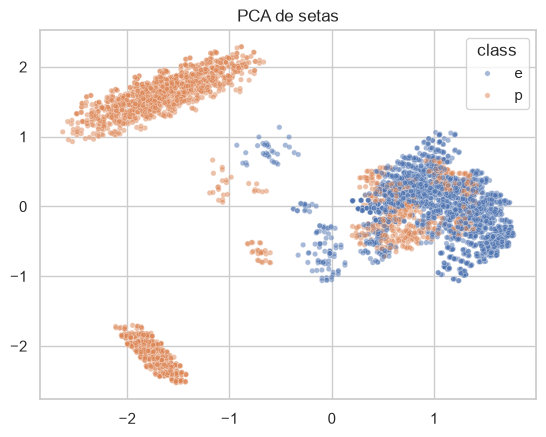

In [12]:
pca=PCA(2,random_state=RANDOM_STATE); X_train_pca2=pca.fit_transform(X_train); sns.scatterplot(x=X_train_pca2[:,0],y=X_train_pca2[:,1],hue=y_train,s=15,alpha=.5); plt.title("PCA de setas"); plt.show()

Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

In [13]:
baseline_rf=RandomForestClassifier(n_estimators=100,random_state=RANDOM_STATE,n_jobs=-1).fit(X_train,y_train); print("Precision:",accuracy_score(y_test,baseline_rf.predict(X_test)))

Precision: 1.0


Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [14]:
X_train.shape

(5443, 115)

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

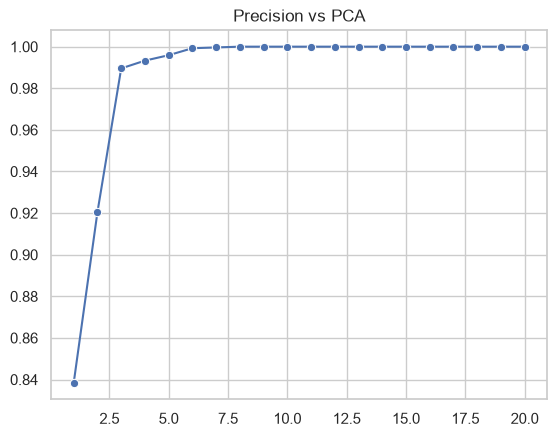

In [15]:
n_features=range(1,21); scores=[]
for n in n_features:
 p=PCA(n,random_state=RANDOM_STATE); a=p.fit_transform(X_train); b=p.transform(X_test); r=RandomForestClassifier(n_estimators=100,random_state=RANDOM_STATE,n_jobs=-1).fit(a,y_train); scores.append(accuracy_score(y_test,r.predict(b)))
sns.lineplot(x=list(n_features),y=scores,marker="o"); plt.title("Precision vs PCA"); plt.show()

A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

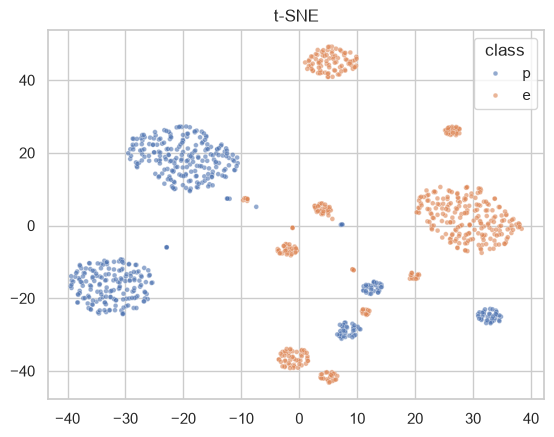

In [16]:
sample=X_train.sample(min(1000,len(X_train)),random_state=RANDOM_STATE); emb=TSNE(2,random_state=RANDOM_STATE,init="pca",learning_rate="auto").fit_transform(sample); sns.scatterplot(x=emb[:,0],y=emb[:,1],hue=y_train.loc[sample.index],s=12,alpha=.6); plt.title("t-SNE"); plt.show()

---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

In [17]:
pca_cluster=PCA(10,random_state=RANDOM_STATE); X_red=pca_cluster.fit_transform(X); print(pca_cluster.explained_variance_ratio_.sum())

0.645213062919939


### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

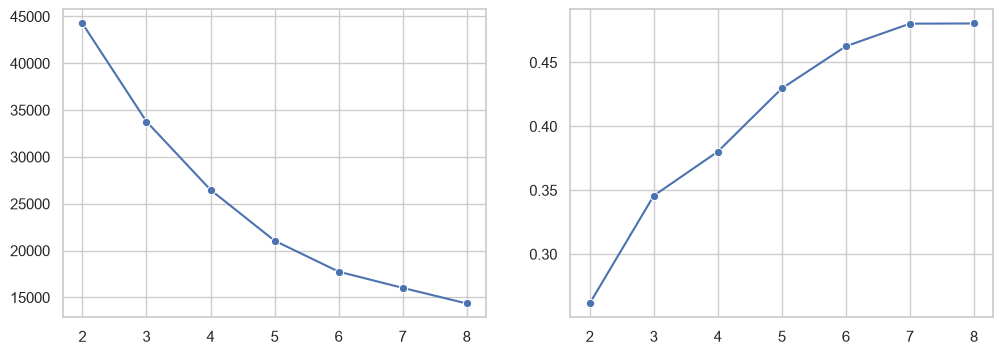

In [18]:
k_values=range(2,9); inercias=[]; silhouettes=[]
for k in k_values:
 km=KMeans(k,n_init=20,random_state=RANDOM_STATE).fit(X_red); inercias.append(km.inertia_); silhouettes.append(silhouette_score(X_red,km.labels_))
fig,ax=plt.subplots(1,2,figsize=(12,4)); sns.lineplot(x=list(k_values),y=inercias,marker="o",ax=ax[0]); sns.lineplot(x=list(k_values),y=silhouettes,marker="o",ax=ax[1]); plt.show()

### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

k 8 ARI 0.26465611214007156 NMI 0.39275016274767854


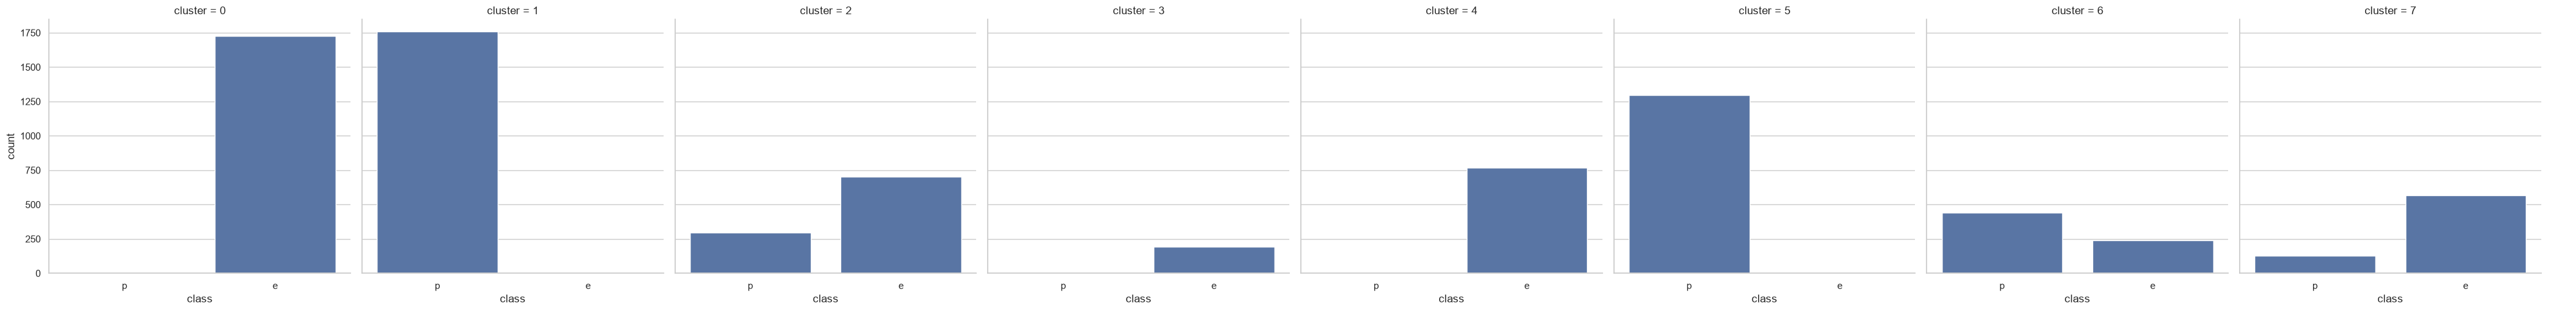

In [19]:
best_k=list(k_values)[int(np.argmax(silhouettes))]; kmeans=KMeans(best_k,n_init=20,random_state=RANDOM_STATE); labels_kmeans=kmeans.fit_predict(X_red); y_bin=(y=="p").astype(int); print("k",best_k,"ARI",adjusted_rand_score(y_bin,labels_kmeans),"NMI",normalized_mutual_info_score(y_bin,labels_kmeans)); sns.catplot(data=pd.DataFrame({"cluster":labels_kmeans,"class":y}),col="cluster",x="class",kind="count"); plt.show()

> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

In [20]:
def evaluar(nombre,labels,datos):
 ok=np.asarray(labels)!=-1; labs=np.asarray(labels)[ok]; dat=np.asarray(datos)[ok]; valid=len(np.unique(labs))>1
 return {"algoritmo":nombre,"clusters":len(np.unique(labs)),"ruido":int((~ok).sum()),"silhouette":silhouette_score(dat,labs) if valid else np.nan,"davies_bouldin":davies_bouldin_score(dat,labs) if valid else np.nan,"calinski_harabasz":calinski_harabasz_score(dat,labs) if valid else np.nan,"ARI":adjusted_rand_score(y_bin.iloc[np.where(ok)[0]],labs)}
agg=AgglomerativeClustering(best_k).fit_predict(X_red); gmm=GaussianMixture(best_k,random_state=RANDOM_STATE).fit_predict(X_red); db=DBSCAN(eps=1.25,min_samples=10).fit_predict(X_red); pd.DataFrame([evaluar("KMeans",labels_kmeans,X_red),evaluar("Aglomerativo",agg,X_red),evaluar("GMM",gmm,X_red),evaluar("DBSCAN",db,X_red)]).round(3)

,algoritmo,clusters,ruido,silhouette,davies_bouldin,calinski_harabasz,ARI
0,KMeans,8,0,0.480,1.068,3542.556,0.265
1,Aglomerativo,8,0,0.482,1.204,3501.685,0.265
2,GMM,8,0,0.479,1.077,3531.120,0.262
3,DBSCAN,17,0,0.353,1.086,2303.197,0.179


### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

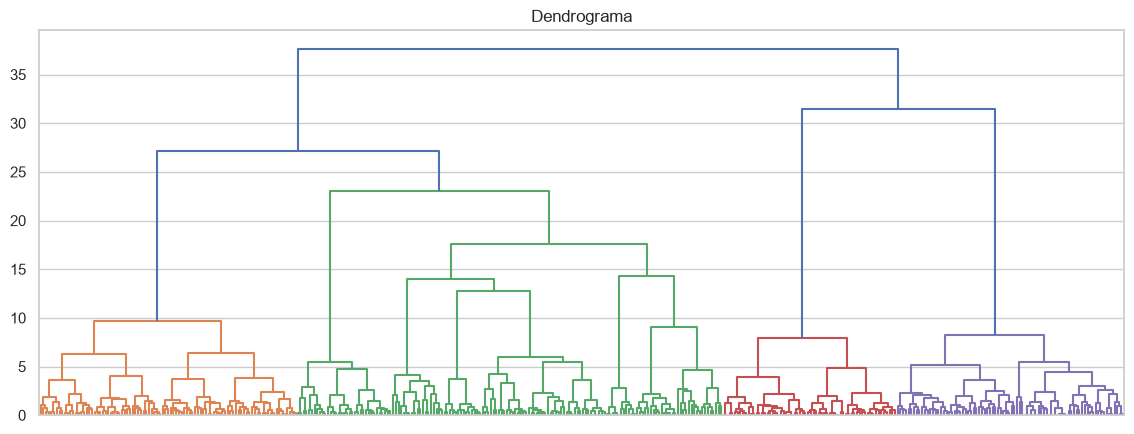

In [21]:
idx=np.random.default_rng(RANDOM_STATE).choice(len(X_red),400,replace=False); plt.figure(figsize=(14,5)); dendrogram(linkage(X_red[idx],method="ward"),no_labels=True); plt.title("Dendrograma"); plt.show()

### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [22]:
idx=np.random.default_rng(RANDOM_STATE).choice(len(X),min(2500,len(X)),replace=False); eu=DBSCAN(eps=1.25,min_samples=10).fit_predict(X_red[idx]); ja=DBSCAN(eps=.35,min_samples=8,metric="jaccard").fit_predict(X.iloc[idx].astype(bool)); print("ARI euclidea",adjusted_rand_score(y_bin.iloc[idx],eu),"ARI Jaccard",adjusted_rand_score(y_bin.iloc[idx],ja))

ARI euclidea 0.18423049066113256 ARI Jaccard 0.3252696084858631


> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

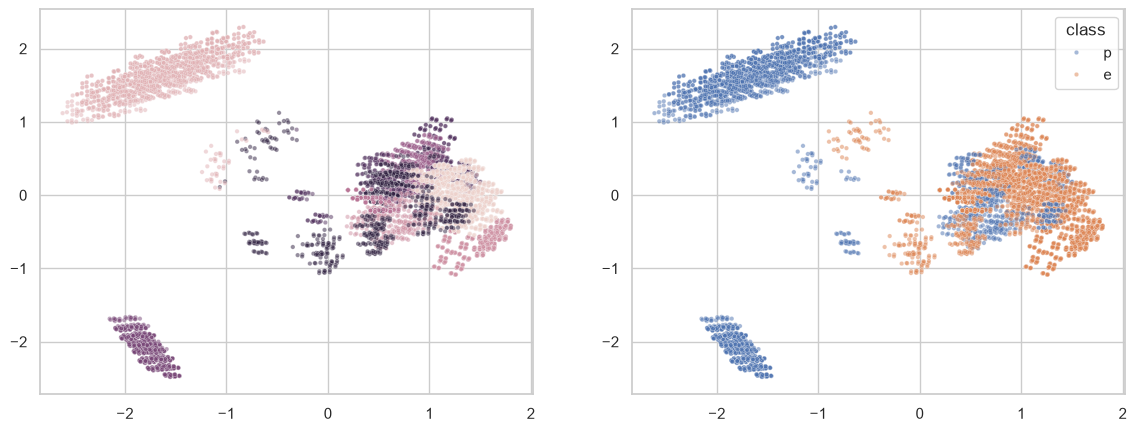

In [23]:
pca_final=PCA(2,random_state=RANDOM_STATE); z=pca_final.fit_transform(X); fig,ax=plt.subplots(1,2,figsize=(14,5)); sns.scatterplot(x=z[:,0],y=z[:,1],hue=labels_kmeans,s=10,alpha=.5,legend=False,ax=ax[0]); sns.scatterplot(x=z[:,0],y=z[:,1],hue=y,s=10,alpha=.5,ax=ax[1]); plt.show()

Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

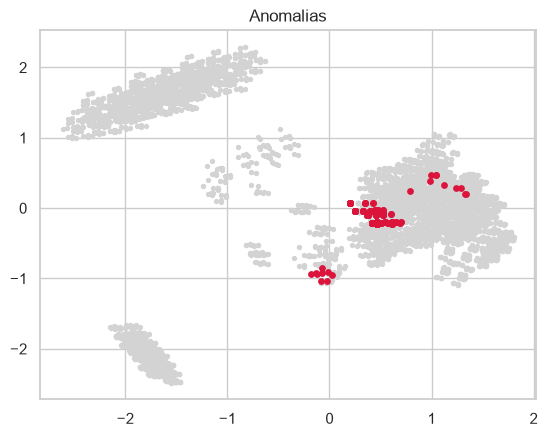

In [24]:
iso=IsolationForest(contamination=.02,random_state=RANDOM_STATE); anomaly_labels=iso.fit_predict(X_red); plt.scatter(z[:,0],z[:,1],s=8,c="lightgray"); plt.scatter(z[anomaly_labels==-1,0],z[anomaly_labels==-1,1],s=15,c="crimson"); plt.title("Anomalias"); plt.show()

## Para ir mas alla (opcional)
Extensiones reproducibles para explorar proyecciones no lineales, densidad y reglas.

In [ ]:
try:
 import umap,hdbscan
except ImportError: print("Instala: pip install umap-learn hdbscan")
else:
 u=umap.UMAP(random_state=RANDOM_STATE).fit_transform(X); h=hdbscan.HDBSCAN(min_cluster_size=30).fit_predict(X); sns.scatterplot(x=u[:,0],y=u[:,1],hue=h,s=10,legend=False); plt.title("UMAP + HDBSCAN"); plt.show()

In [ ]:
try:
 from mlxtend.frequent_patterns import apriori,association_rules
except ImportError: print("Instala: pip install mlxtend")
else:
 items=apriori(X.sample(min(2000,len(X)),random_state=RANDOM_STATE).astype(bool),min_support=.1,max_len=2,use_colnames=True); association_rules(items,metric="lift",min_threshold=1.2)[["antecedents","consequents","support","confidence","lift"]].sort_values("lift",ascending=False).head(10)

## Conclusiones
PCA y t-SNE hacen visible la estructura; ARI/NMI validan clusters sin usarse para entrenar; la distancia Jaccard es adecuada para variables binarias.